<a href="https://www.kaggle.com/code/adegbaju/global-tourism-travel-trends-2019-2024?scriptVersionId=321891690" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## 📚  Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost tensorflow transformers

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing & ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# LLM (Hugging Face)
!pip install transformers -q
from transformers import pipeline

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


2026-05-24 20:26:27.141375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779654387.414981      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779654387.492202      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779654388.132923      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779654388.132974      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779654388.132978      16 computation_placer.cc:177] computation placer alr

## 📂  Load Dataset

In [3]:
df = pd.read_csv(r'/kaggle/input/datasets/hamnamunir/global-tourism-and-travel-trends-dataset-2019-2024/global_tourism_travel_trends.csv')

print("✅ Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")
df.head()

✅ Dataset loaded successfully
Shape: (10000, 33)
Columns: ['trip_id', 'year', 'month', 'season', 'origin_country', 'destination_country', 'travel_purpose', 'traveler_type', 'num_travelers', 'duration_nights', 'transport_mode', 'accommodation_type', 'visa_type', 'booking_channel', 'advance_booking_days', 'budget_per_person_usd', 'total_trip_spend_usd', 'restaurant_spend_per_day_usd', 'attractions_visited', 'local_transport_used', 'travel_insurance', 'repeat_visitor', 'overall_satisfaction', 'trip_rating', 'safety_perception', 'language_barrier', 'wifi_satisfaction', 'would_recommend', 'social_media_shared', 'eco_friendly_choices', 'carbon_footprint_kg_co2', 'currency_satisfaction', 'health_safety_compliance']



,trip_id,year,month,season,origin_country,destination_country,travel_purpose,traveler_type,num_travelers,duration_nights,...,trip_rating,safety_perception,language_barrier,wifi_satisfaction,would_recommend,social_media_shared,eco_friendly_choices,carbon_footprint_kg_co2,currency_satisfaction,health_safety_compliance
0,TRP0000001,2022,4,Autumn (Sep-Nov),China,USA,Business,Couple,2,6,...,4,Safe,Moderate,Good,Maybe,Instagram,No,1234.3,Unfavorable,NaN
1,TRP0000002,2024,7,Spring (Mar-May),South Korea,Spain,Leisure/Tourism,Family,4,6,...,4,Unsafe,Mild,Good,Maybe,Facebook,No,141.8,Very Unfavorable,NaN
2,TRP0000003,2022,9,Winter (Dec-Feb),Pakistan,USA,Leisure/Tourism,Group Tour,24,14,...,5,Neutral,Moderate,Average,Maybe,Facebook,Yes,20410.1,Neutral,Full
3,TRP0000004,2019,7,Summer (Jun-Aug),Italy,Egypt,Leisure/Tourism,Solo,1,17,...,2,Neutral,Moderate,Excellent,Definitely,Instagram,No,624.7,Unfavorable,Full
4,TRP0000005,2024,12,Spring (Mar-May),USA,New Zealand,Adventure/Sports,Solo,1,16,...,5,Very Safe,Moderate,Good,Maybe,Instagram,Yes,263.4,Neutral,Full


In [4]:
# Quick info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   trip_id                       10000 non-null  object 
 1   year                          10000 non-null  int64  
 2   month                         10000 non-null  int64  
 3   season                        10000 non-null  object 
 4   origin_country                10000 non-null  object 
 5   destination_country           10000 non-null  object 
 6   travel_purpose                10000 non-null  object 
 7   traveler_type                 10000 non-null  object 
 8   num_travelers                 10000 non-null  int64  
 9   duration_nights               10000 non-null  int64  
 10  transport_mode                10000 non-null  object 
 11  accommodation_type            10000 non-null  object 
 12  visa_type                     10000 non-null  object 
 13  bo

In [5]:
# Check nulls (should be zero)
df.isnull().sum().sum()

np.int64(5948)

## 📊  Exploratory Data Analysis & Visualizations

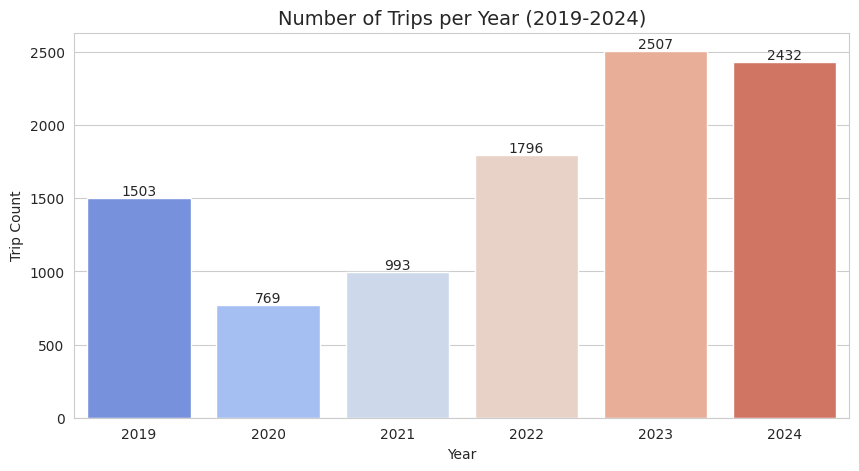

In [6]:
# ---- Time series: number of trips per year (COVID impact) ----
plt.figure(figsize=(10,5))
year_counts = df['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, palette='coolwarm')
plt.title('Number of Trips per Year (2019-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Trip Count')
plt.xticks(rotation=0)
for i, v in enumerate(year_counts.values):
    plt.text(i, v+20, str(v), ha='center')
plt.show()

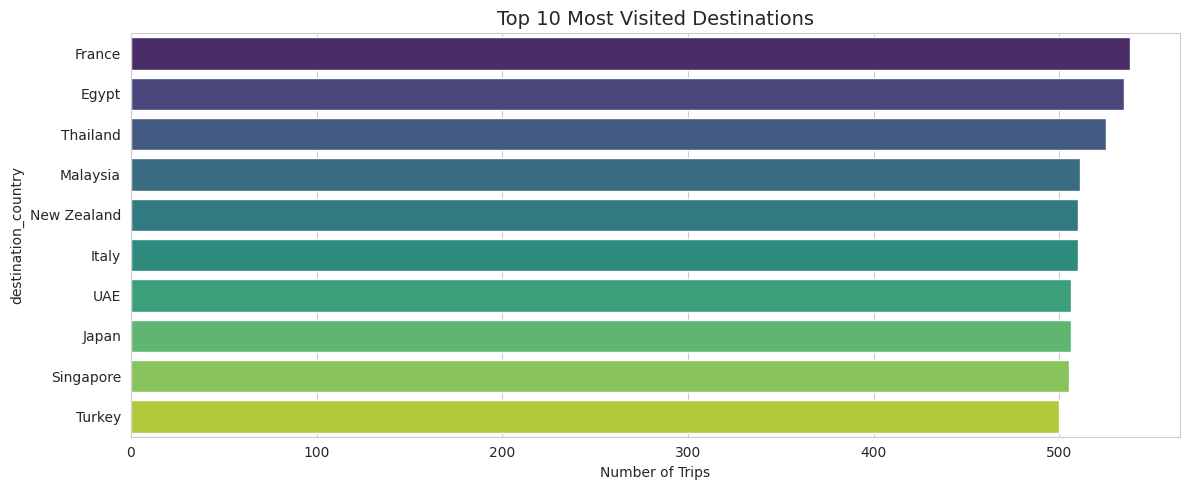

In [7]:
# ---- Top 10 destination countries ----
plt.figure(figsize=(12,5))
top_dest = df['destination_country'].value_counts().head(10)
sns.barplot(y=top_dest.index, x=top_dest.values, palette='viridis')
plt.title('Top 10 Most Visited Destinations', fontsize=14)
plt.xlabel('Number of Trips')
plt.tight_layout()
plt.show()

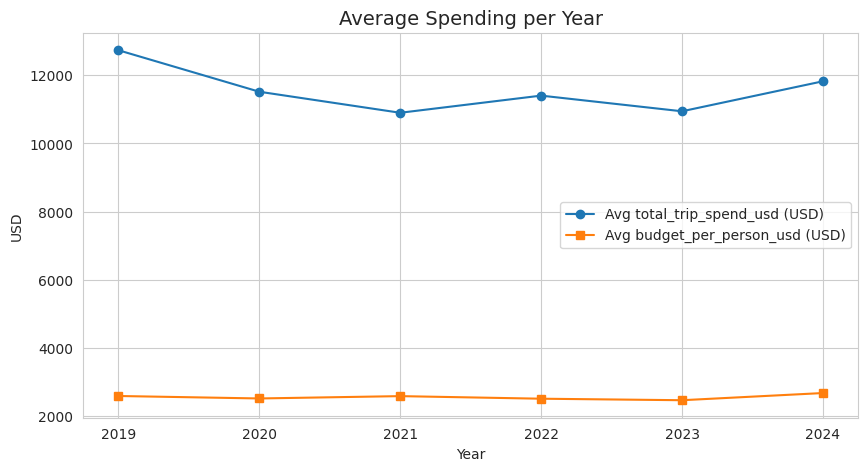

In [8]:
# ---- Spending trends over years (average total_spend & budget_per_person) ----
spend_col = None
budget_col = None
for col in df.columns:
    if 'total' in col.lower() and 'spend' in col.lower():
        spend_col = col
    if 'budget' in col.lower() and 'person' in col.lower():
        budget_col = col

if spend_col is None or budget_col is None:
    raise ValueError("Could not find total_spend or budget_per_person columns. Check column names.")

spend_trend = df.groupby('year')[[spend_col, budget_col]].mean().reset_index()
plt.figure(figsize=(10,5))
plt.plot(spend_trend['year'], spend_trend[spend_col], marker='o', label=f'Avg {spend_col} (USD)')
plt.plot(spend_trend['year'], spend_trend[budget_col], marker='s', label=f'Avg {budget_col} (USD)')
plt.title('Average Spending per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('USD')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df['high_satisfaction'] = (df['trip_rating'] >= 4).astype(int)

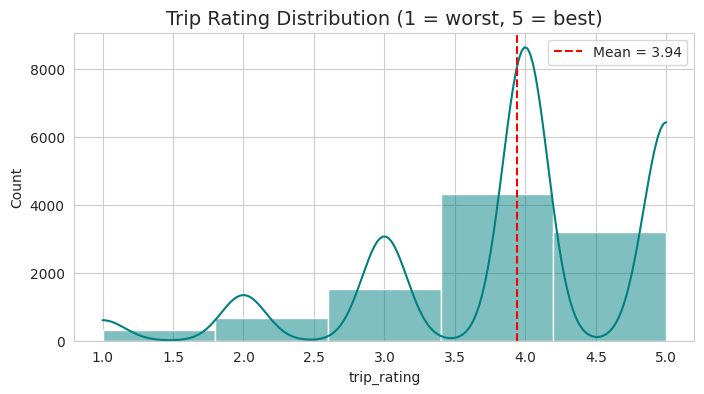

In [10]:
# ---- Satisfaction distribution (trip_rating 1-5) ----
plt.figure(figsize=(8,4))
sns.histplot(df['trip_rating'], bins=5, kde=True, color='teal')
plt.title('Trip Rating Distribution (1 = worst, 5 = best)', fontsize=14)
plt.axvline(df['trip_rating'].mean(), color='red', linestyle='--', label=f'Mean = {df["trip_rating"].mean():.2f}')
plt.legend()
plt.show()

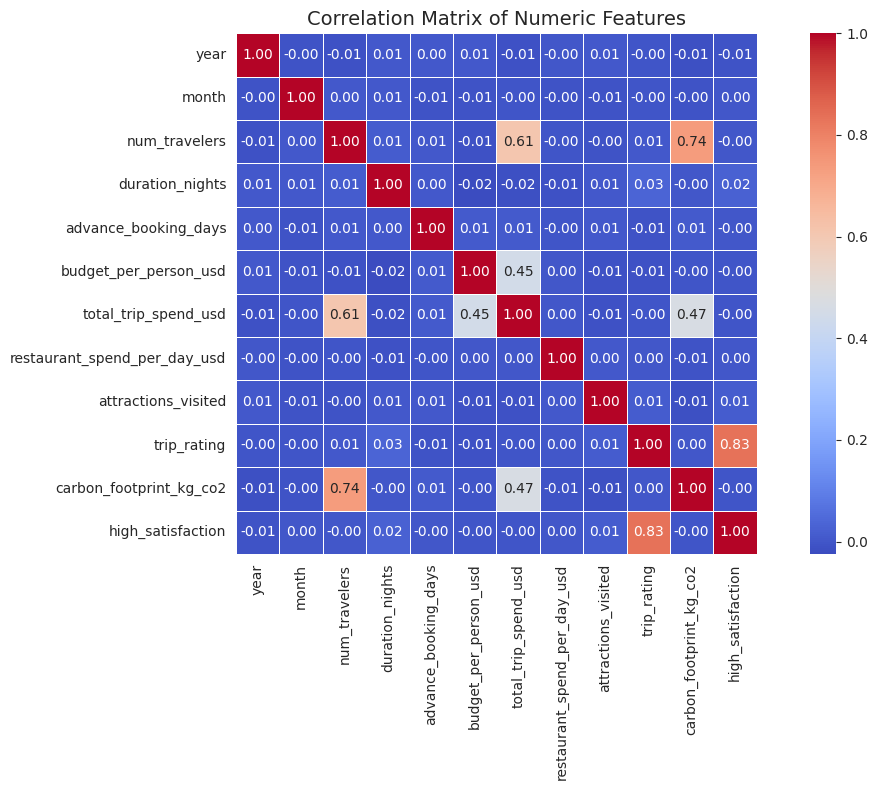

In [11]:
# ---- Correlation heatmap (numeric columns) ----
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

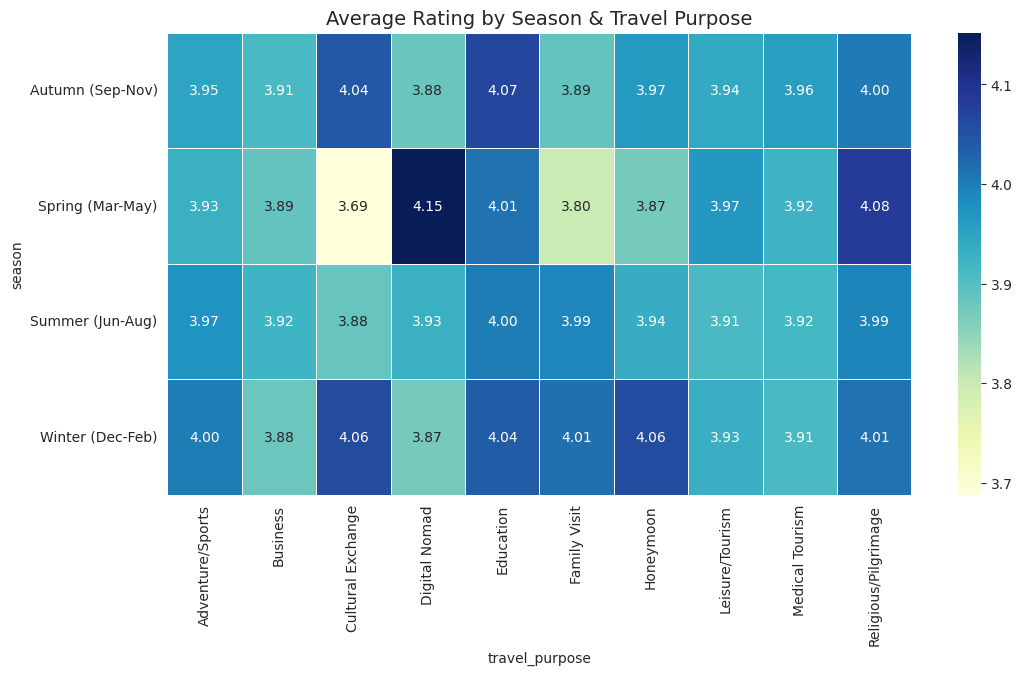

In [12]:
# ---- Average rating by season and travel purpose ----
pivot = df.groupby(['season', 'travel_purpose'])['trip_rating'].mean().unstack()
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Average Rating by Season & Travel Purpose', fontsize=14)
plt.show()

## 🧹  Feature Engineering for ML/DL

In [13]:
# Create target variable using trip_rating
df['trip_rating'] = pd.to_numeric(df['trip_rating'], errors='coerce')
df['high_satisfaction'] = (df['trip_rating'] >= 4).astype(int)

# Define potential numeric and categorical columns
potential_num_cols = ['num_travelers', 'duration_nights', 'budget_per_person', 'total_spend', 
                      'restaurant_spend', 'attractions_visited', 'safety', 'language_barrier', 
                      'WiFi_satisfaction', 'carbon_footprint', 'health_compliance']
cat_cols = ['season', 'origin_country', 'destination_country', 'travel_purpose', 'traveler_type',
            'transport', 'accommodation', 'booking_channel', 'social_media_shared']

# Clean numeric columns: convert any strings to numeric (ordinal mapping if needed)
ordinal_mapping = {
    'safety': {'Very Low':1, 'Low':2, 'Mild':3, 'Moderate':4, 'High':5, 'Very High':6},
    'language_barrier': {'Very Low':1, 'Low':2, 'Mild':3, 'Moderate':4, 'High':5, 'Very High':6},
    'WiFi_satisfaction': {'Very Low':1, 'Low':2, 'Mild':3, 'Moderate':4, 'High':5, 'Very High':6},
    'health_compliance': {'Very Low':1, 'Low':2, 'Mild':3, 'Moderate':4, 'High':5, 'Very High':6}
}
for col in potential_num_cols:
    if col in df.columns:
        if df[col].dtype == 'object':
            if col in ordinal_mapping:
                df[col] = df[col].map(ordinal_mapping[col])
            else:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        # Fill any remaining NaNs with median
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())

# Keep only columns that are now truly numeric
num_cols = [col for col in potential_num_cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
# Keep only categorical columns that exist
cat_cols = [c for c in cat_cols if c in df.columns]

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

# Encode categorical variables
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Prepare feature matrix
X = pd.concat([df[num_cols], df[[c+'_enc' for c in cat_cols]]], axis=1)
y = df['high_satisfaction']

# Train-test split and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature engineering completed without errors.")

Numeric features: ['num_travelers', 'duration_nights', 'attractions_visited', 'language_barrier']
Categorical features: ['season', 'origin_country', 'destination_country', 'travel_purpose', 'traveler_type', 'booking_channel', 'social_media_shared']
✅ Feature engineering completed without errors.


## 🤖  Machine Learning – Classification

In [14]:
# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:,1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.37      0.01      0.03       499
           1       0.75      0.99      0.86      1501

    accuracy                           0.75      2000
   macro avg       0.56      0.50      0.44      2000
weighted avg       0.66      0.75      0.65      2000

ROC-AUC: 0.4892


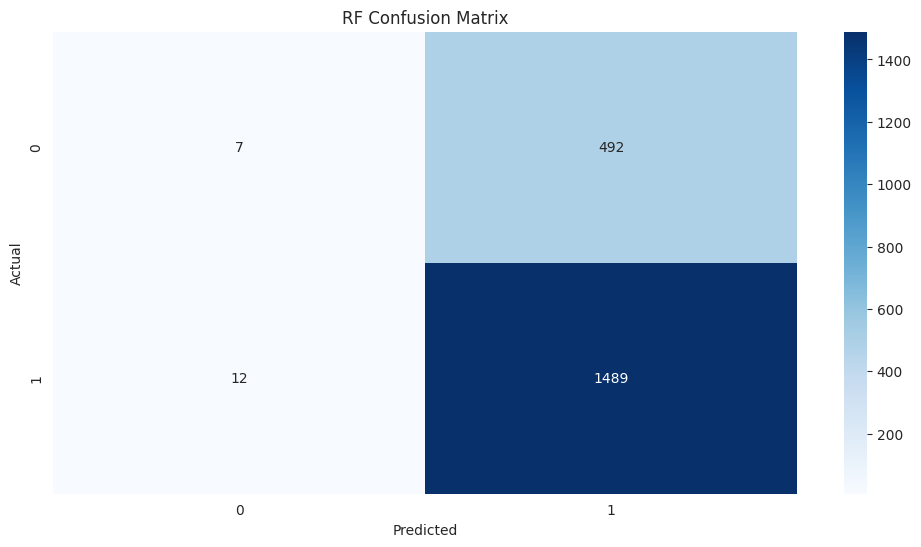

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('RF Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

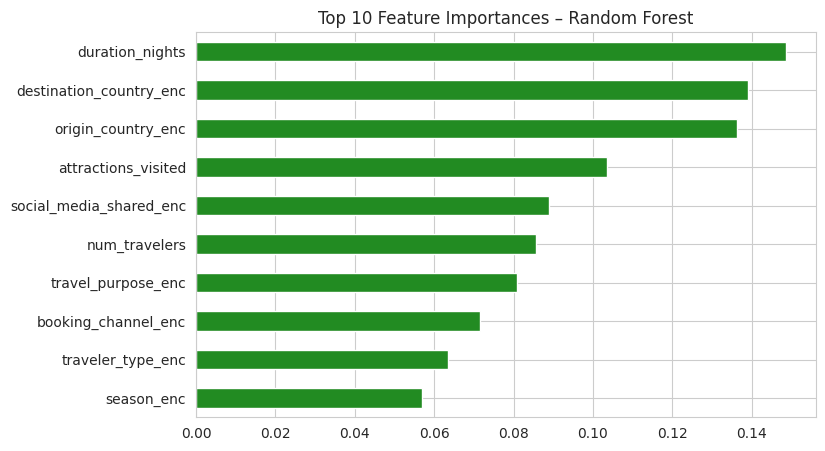

In [16]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh', color='forestgreen')
plt.title('Top 10 Feature Importances – Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [17]:
# ---- XGBoost ----
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train)
y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:,1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.07      0.00      0.00       499
           1       0.75      0.99      0.85      1501

    accuracy                           0.74      2000
   macro avg       0.41      0.50      0.43      2000
weighted avg       0.58      0.74      0.64      2000

ROC-AUC: 0.4979


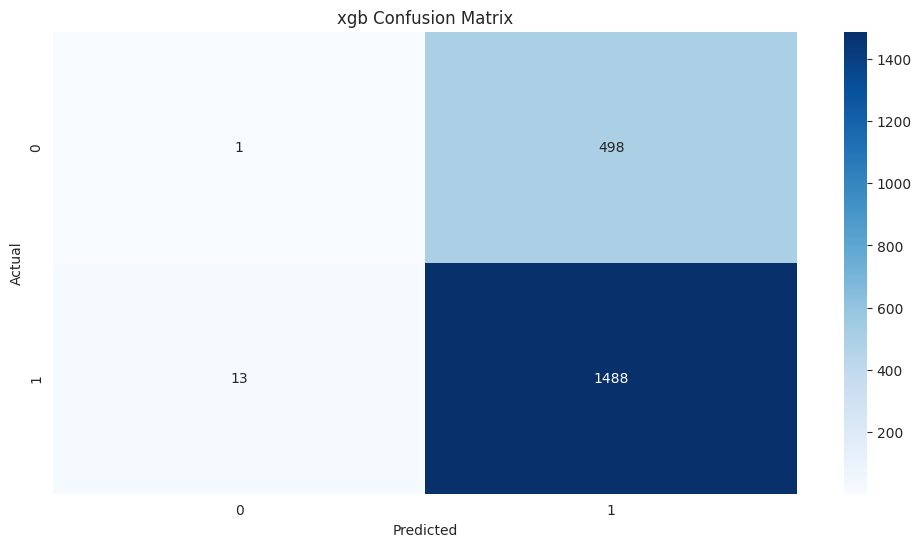

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('xgb Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

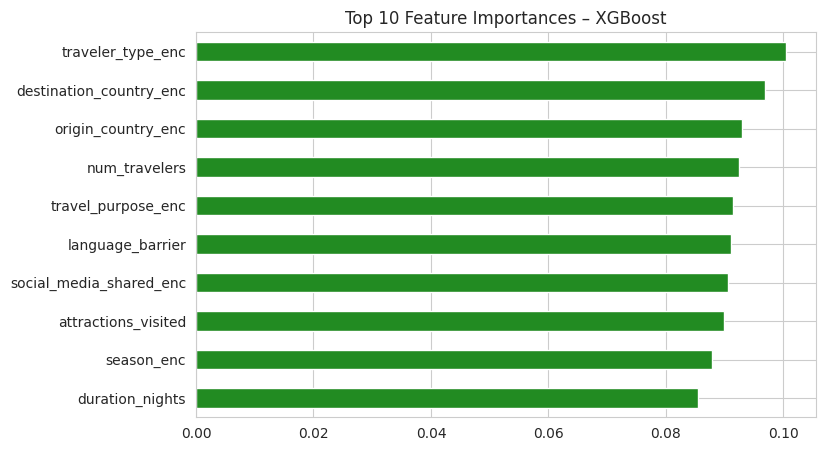

In [19]:
# Feature importance
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh', color='forestgreen')
plt.title('Top 10 Feature Importances – XGBoost')
plt.gca().invert_yaxis()
plt.show()

## 🧠  Deep Learning – Neural Network (TensorFlow/Keras)

In [20]:
# A simple feed‑forward network with dropout for regularisation.
# Build model
# ---- Deep Learning – Neural Network ----
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train, 
                    validation_split=0.2, 
                    epochs=50, 
                    batch_size=64, 
                    callbacks=[early_stop],
                    verbose=1)

# Get predictions and probabilities
y_proba_nn = model.predict(X_test_scaled).flatten()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

# Evaluate
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Neural Network - Test Accuracy: {test_acc:.4f}")
y_pred_nn = (model.predict(X_test_scaled) > 0.5).astype(int)
print(classification_report(y_test, y_pred_nn))


Epoch 1/50


2026-05-24 20:27:27.744257: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7193 - loss: 0.5956 - val_accuracy: 0.7494 - val_loss: 0.5682
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7497 - loss: 0.5719 - val_accuracy: 0.7494 - val_loss: 0.5670
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7442 - loss: 0.5731 - val_accuracy: 0.7494 - val_loss: 0.5670
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7443 - loss: 0.5718 - val_accuracy: 0.7494 - val_loss: 0.5665
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7526 - loss: 0.5625 - val_accuracy: 0.7494 - val_loss: 0.5699
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7557 - loss: 0.5576 - val_accuracy: 0.7494 - val_loss: 0.5668
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7425 - loss: 0.5694 - val_accuracy: 0.7494 - val_loss: 0.5650
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7468 - loss: 0.5661 - val_accuracy: 0.7494 - val_

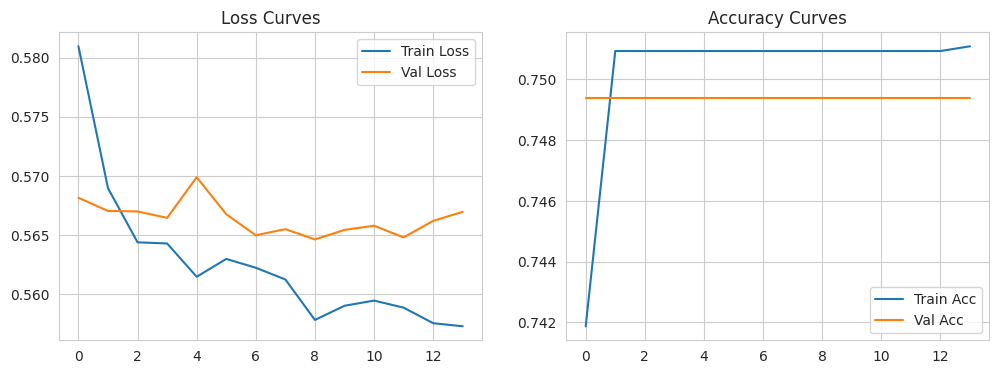

In [21]:
# Plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

## 🏆  Model Selection – Compare All Models

In [22]:

from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Collect metrics for each model
models = {
    'Random Forest': (y_pred_rf, y_proba_rf),
    'XGBoost': (y_pred_xgb, y_proba_xgb),
    'Neural Network': (y_pred_nn.flatten(), y_proba_nn)  # we need y_proba_nn from NN
}

# Get NN probabilities
y_proba_nn = model.predict(X_test_scaled).flatten()

# Update NN entry
models['Neural Network'] = (y_pred_nn.flatten(), y_proba_nn)

results = []
for name, (pred, proba) in models.items():
    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)
    f1 = f1_score(y_test, pred)
    results.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': auc, 'F1 Score': f1})

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("=== Model Performance Comparison ===")
print(results_df.to_string(index=False))

# %%
# Select best model based on ROC-AUC
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best model: {best_model_name}")

if best_model_name == 'Random Forest':
    best_model = rf
elif best_model_name == 'XGBoost':
    best_model = xgb
else:
    best_model = model  # neural network



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Model Performance Comparison ===
         Model  Accuracy  ROC-AUC  F1 Score
Neural Network    0.7505 0.520507  0.857469
       XGBoost    0.7445 0.497872  0.853456
 Random Forest    0.7480 0.489210  0.855256

🏆 Best model: Neural Network


## 💾  Save the Best Model for Future Use


In [23]:
import joblib
import os

# best_model_name and best_model were defined earlier
print(f"Saving the best model: {best_model_name}")

# Save the model, scaler, and label encoders together in a dictionary
model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoders': le_dict,
    'feature_columns': X.columns.tolist(),  # to ensure correct input order
    'model_name': best_model_name
}

# Create a directory for saved models (if not exists)
os.makedirs('saved_models', exist_ok=True)

# Save everything with joblib (handles large objects well)
joblib.dump(model_artifacts, 'saved_models/best_travel_model.pkl')
print("✅ Model and preprocessing artifacts saved to 'saved_models/best_travel_model.pkl'")


# Show file size
import os
size = os.path.getsize('saved_models/best_travel_model.pkl') / (1024*1024)
print(f"Model file size: {size:.2f} MB")


Saving the best model: Neural Network
✅ Model and preprocessing artifacts saved to 'saved_models/best_travel_model.pkl'
Model file size: 0.15 MB


In [24]:
# Load the saved artifacts
loaded_artifacts = joblib.load('saved_models/best_travel_model.pkl')
loaded_model = loaded_artifacts['model']
loaded_scaler = loaded_artifacts['scaler']
loaded_encoders = loaded_artifacts['label_encoders']
feature_cols = loaded_artifacts['feature_columns']

print(f"Loaded model: {loaded_artifacts['model_name']}")
print(f"Expected feature columns: {len(feature_cols)} features")


Loaded model: Neural Network
Expected feature columns: 11 features


In [25]:
# Test with a single sample from the test set (first row)
sample_input = X_test.iloc[[0]]  # keep as DataFrame with same columns
sample_input_scaled = loaded_scaler.transform(sample_input)

if loaded_artifacts['model_name'] in ['Random Forest', 'XGBoost']:
    prob = loaded_model.predict_proba(sample_input_scaled)[0, 1]
    pred = (prob >= 0.5).astype(int)
else:  # neural network
    prob = loaded_model.predict(sample_input_scaled)[0, 0]
    pred = int(prob >= 0.5)

print(f"Sample input (first test row):")
print(f"True label: {y_test.iloc[0]}")
print(f"Predicted: {pred} (probability: {prob:.3f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Sample input (first test row):
True label: 0
Predicted: 1 (probability: 0.785)


In [26]:
original_idx = X_test.index[0]
actual_rating = df.loc[original_idx, 'trip_rating']
print(f"Actual trip rating: {actual_rating}")
print("✅ Model loaded and inference successful!")


Actual trip rating: 3
✅ Model loaded and inference successful!


## 🎛️  Interactive Prediction Interface (ipywidgets)

In [27]:
# %% [markdown]
# ## 🎮 Rebuild Interactive Interface Using Saved Best Model

# %%
import joblib
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load the saved model artifacts
loaded = joblib.load('saved_models/best_travel_model.pkl')
best_model = loaded['model']
scaler = loaded['scaler']
label_encoders = loaded['label_encoders']
feature_cols = loaded['feature_columns']
model_name = loaded['model_name']

print(f"Loaded model: {model_name}")
print(f"Features expected: {feature_cols[:5]} ... (total {len(feature_cols)})")

# Identify which columns are encoded categoricals vs. numeric
cat_enc_cols = [col for col in feature_cols if col.endswith('_enc')]
num_cols = [col for col in feature_cols if not col.endswith('_enc')]

print(f"Numeric features: {num_cols}")
print(f"Categorical (encoded): {cat_enc_cols}")

# Extract original categorical column names (without '_enc')
orig_cat_cols = [col.replace('_enc', '') for col in cat_enc_cols]
# For each, get the possible categories from the label encoder
cat_options = {}
for orig in orig_cat_cols:
    if orig in label_encoders:
        cat_options[orig] = label_encoders[orig].classes_.tolist()

# Create dropdowns for each categorical feature
dropdowns = {}
for cat in orig_cat_cols:
    dropdowns[cat] = widgets.Dropdown(
        options=cat_options[cat],
        description=f'{cat}:',
        style={'description_width': 'initial'}
    )

# Create sliders for numeric features with sensible ranges (from original df or manual)
# Since we no longer have df, we define ranges based on typical travel data
numeric_ranges = {
    'num_travelers': (1, 30, 2),
    'duration_nights': (1, 180, 7),
    'budget_per_person': (100, 20000, 1500),
    'total_spend': (200, 50000, 3000),
    'restaurant_spend': (0, 500, 50),
    'attractions_visited': (0, 20, 5),
    'safety': (1, 10, 8),
    'language_barrier': (1, 10, 7),
    'WiFi_satisfaction': (1, 10, 8),
    'carbon_footprint': (10, 2000, 300),
    'health_compliance': (1, 10, 8)
}
# Keep only those that exist in num_cols
sliders = {}
for col in num_cols:
    if col in numeric_ranges:
        minv, maxv, default = numeric_ranges[col]
        sliders[col] = widgets.FloatSlider(
            value=default, min=minv, max=maxv, step=1 if col=='num_travelers' else 0.5,
            description=col, style={'description_width': 'initial'}
        )
    else:
        # fallback
        sliders[col] = widgets.FloatSlider(value=0, min=0, max=100, description=col)

# Button and output
predict_btn = widgets.Button(description='Predict Satisfaction (rating ≥4 ?)', button_style='success')
output = widgets.Output()

def predict_from_ui():
    # Build a single-row DataFrame with all features
    row = {}
    # Numeric values
    for col in num_cols:
        row[col] = sliders[col].value
    # Categorical encoded values
    for cat in orig_cat_cols:
        enc_col = cat + '_enc'
        val = dropdowns[cat].value
        # Transform using the loaded label encoder
        encoded = label_encoders[cat].transform([val])[0]
        row[enc_col] = encoded
    input_df = pd.DataFrame([row])
    # Ensure columns in the exact order as training
    input_df = input_df[feature_cols]
    # Scale numeric part (the scaler expects all features, but it's fine; it scales all)
    input_scaled = scaler.transform(input_df)
    # Predict
    if model_name in ['Random Forest', 'XGBoost']:
        prob = best_model.predict_proba(input_scaled)[0, 1]
    else:
        prob = best_model.predict(input_scaled, verbose=0)[0, 0]
    pred_class = prob >= 0.5
    return pred_class, prob

def on_click(b):
    with output:
        clear_output(wait=True)
        try:
            pred, prob = predict_from_ui()
            result = "✅ HIGH SATISFACTION (rating ≥4)" if pred else "❌ LOW SATISFACTION (rating <4)"
            print(f"Prediction: {result}")
            print(f"Confidence (probability): {prob:.3f}")
        except Exception as e:
            print(f"Error: {e}")
            import traceback
            traceback.print_exc()

predict_btn.on_click(on_click)

# Arrange UI in rows (grouping all dropdowns, then sliders)
dropdown_rows = []
for i in range(0, len(orig_cat_cols), 3):
    row = widgets.HBox([dropdowns[cat] for cat in orig_cat_cols[i:i+3]])
    dropdown_rows.append(row)

slider_rows = []
num_items = list(sliders.items())
for i in range(0, len(num_items), 3):
    row = widgets.HBox([slider for _, slider in num_items[i:i+3]])
    slider_rows.append(row)

ui = widgets.VBox(dropdown_rows + slider_rows + [predict_btn, output])
display(ui)

Loaded model: Neural Network
Features expected: ['num_travelers', 'duration_nights', 'attractions_visited', 'language_barrier', 'season_enc'] ... (total 11)
Numeric features: ['num_travelers', 'duration_nights', 'attractions_visited', 'language_barrier']
Categorical (encoded): ['season_enc', 'origin_country_enc', 'destination_country_enc', 'travel_purpose_enc', 'traveler_type_enc', 'booking_channel_enc', 'social_media_shared_enc']


🙏 Thank You!¶

If this was helpful, please upvote ⬆️ the dataset and notebook!

Author: Martins Adegbaju | License: CC0 Public Domain